In [1]:
%matplotlib inline
import requests
import pandas as pd

import os
import sys
path = os.path.abspath('../')
sys.path.append(path)

In [2]:
from cgsn_parsers.parsers.parse_mopak import Parser

In [3]:
# Coastal Endurance Washington Shelf Surface Mooring Buoy MOPAK data
baseurl = "https://rawdata.oceanobservatories.org/files/CE07SHSM/D00003/cg_data/dcl11/mopak/"
fname = "20160505_220005.mopak.log"

# initialize the Parser object for MOPAK
mopak = Parser(baseurl + fname)
r = requests.get(mopak.infile, verify=True) # use verify=False for expired certificate

In [4]:
mopak.raw = r.content
len(mopak.raw), mopak.raw[:5]

(513678, b'\xcb=f\xbb`')

In [5]:
mopak.parse_data()
mopak.data.keys()

dict_keys(['timer', 'acceleration_z', 'time', 'acceleration_y', 'magnetometer_x', 'magnetometer_y', 'angular_rate_z', 'magnetometer_z', 'acceleration_x', 'angular_rate_x', 'angular_rate_y'])

In [6]:
df = pd.DataFrame(mopak.data)
df['dt_utc'] = pd.to_datetime(df.time, unit='s')
df.set_index('dt_utc', drop=False, inplace=True)

In [7]:
df.shape, df.columns

((11946, 12),
 Index(['acceleration_x', 'acceleration_y', 'acceleration_z', 'angular_rate_x',
        'angular_rate_y', 'angular_rate_z', 'magnetometer_x', 'magnetometer_y',
        'magnetometer_z', 'time', 'timer', 'dt_utc'],
       dtype='object'))

In [8]:
df.dtypes

acceleration_x           float64
acceleration_y           float64
acceleration_z           float64
angular_rate_x           float64
angular_rate_y           float64
angular_rate_z           float64
magnetometer_x           float64
magnetometer_y           float64
magnetometer_z           float64
time                     float64
timer                    float64
dt_utc            datetime64[ns]
dtype: object

In [9]:
df.tail(10)

,acceleration_x,acceleration_y,acceleration_z,angular_rate_x,angular_rate_y,angular_rate_z,magnetometer_x,magnetometer_y,magnetometer_z,time,timer,dt_utc
dt_utc,,,,,,,,,,,,
2016-05-05 22:19:59.888296,-0.005430,0.042704,-1.045006,0.031155,-0.137247,0.027704,-0.081574,0.572853,0.572853,1.462487e+09,1194.635296,2016-05-05 22:19:59.888296
2016-05-05 22:19:59.988296,-0.017207,0.047202,-1.063312,0.059731,-0.143670,0.026456,-0.075668,0.571807,0.571807,1.462487e+09,1194.735296,2016-05-05 22:19:59.988296
2016-05-05 22:20:00.088296,-0.029677,0.043938,-1.082298,0.091781,-0.155313,0.029425,-0.069813,0.570695,0.570695,1.462487e+09,1194.835296,2016-05-05 22:20:00.088296
2016-05-05 22:20:00.188296,-0.035908,0.038241,-1.099732,0.122760,-0.153670,0.017790,-0.063289,0.570856,0.570856,1.462487e+09,1194.935296,2016-05-05 22:20:00.188296
2016-05-05 22:20:00.288296,-0.040765,0.024472,-1.112177,0.146258,-0.149758,0.017760,-0.056238,0.571095,0.571095,1.462487e+09,1195.035296,2016-05-05 22:20:00.288296
2016-05-05 22:20:00.388296,-0.041746,0.006197,-1.120037,0.168002,-0.147708,0.015919,-0.049250,0.572169,0.572169,1.462487e+09,1195.135296,2016-05-05 22:20:00.388296
2016-05-05 22:20:00.488296,-0.041878,-0.014394,-1.119089,0.178329,-0.139971,0.020306,-0.042329,0.573373,0.573373,1.462487e+09,1195.235296,2016-05-05 22:20:00.488296
2016-05-05 22:20:00.588296,-0.044921,-0.032331,-1.111984,0.182332,-0.129649,0.018146,-0.036602,0.575260,0.575260,1.462487e+09,1195.335296,2016-05-05 22:20:00.588296
2016-05-05 22:20:00.688296,-0.049843,-0.049711,-1.099116,0.172993,-0.118371,0.013107,-0.029747,0.577821,0.577821,1.462487e+09,1195.435296,2016-05-05 22:20:00.688296


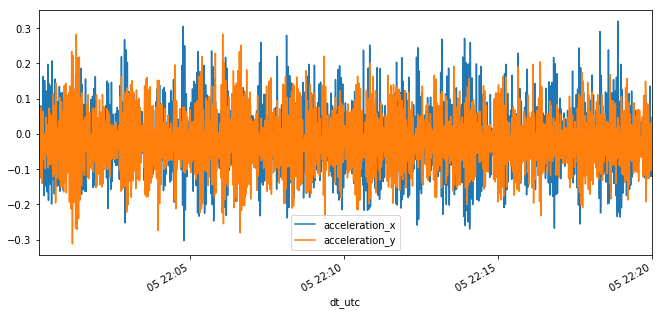

In [10]:
df[['acceleration_x', 'acceleration_y']].plot(figsize=(11,5));

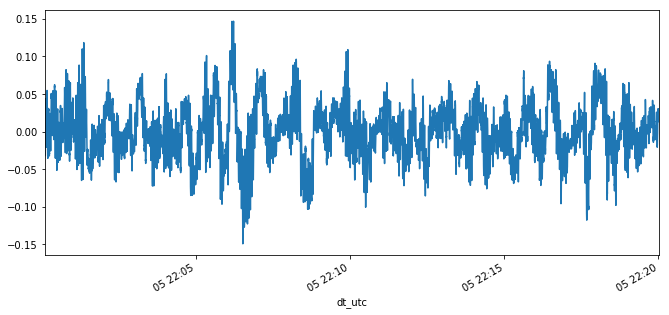

In [11]:
df['angular_rate_z'].plot(figsize=(11,5));